## Hurst Exponent Estimation

See full explanation and results in corresponding [doc](../docs/hurst_estimation.md)

### 1 - Sample Path Analysis

Functions

In [2]:
import math
import numpy as np
from tqdm import tqdm
from scipy import linalg
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Simulation of Bm
# Returns Bm
def Bm(T, m):
    dt = T/m

    # Brownian Motion
    dW = np.sqrt(dt)*np.random.randn(m) 
    W = np.cumsum(dW)

    return W

# Simulation of fBm by Cholesky factorization
# Returns fBm
def fBm(H_choice, grid):
    m = len(grid)
    cov_mat = np.zeros((m,m))

    # Covariance matrix
    for i in tqdm(range(m), desc='fBM', leave=False):
        for j in range(i,m):
            cov_mat[i, j] = 0.5 * (grid[i]**(2*H_choice) + grid[j]**(2*H_choice) - np.abs(grid[i]-grid[j])**(2*H_choice))
            cov_mat[j, i] = cov_mat[i, j]
    cov_mat += np.eye(m) * 1e-10   # To make sure the matrix is strictly positiv  
    
    C = linalg.cholesky(cov_mat, lower=True)
    Z = np.random.normal(0,1,m)
    fW = np.dot(C.T, Z)
    fW[:15] = [0 for k in range(15)]

    return fW

# Returns the means reversions x_i
def x(alpha, rn, i, n):
    return ((1 - alpha) * (rn**(2 - alpha) - 1)) / ((2 - alpha) * (rn**(1 - alpha) - 1)) * rn**(i - 1 - n / 2)

# Returns the weights c_i
def c(alpha, rn, i, n):
    return ((rn**(1 - alpha) - 1) / (math.gamma(alpha) * math.gamma(2 - alpha))) * rn**((1 - alpha) * (i - 1 - n / 2))

# Returns the initial curve g0(t)
def g0(t, V0, lamb, theta, alpha, rn, n):
    inter = 0
    for i in range(1,n+1):
        inter = inter + c(alpha,rn,i,n)*quad(lambda s: np.exp(-x(alpha,rn,i,n)*(t-s)),0,t)[0]
    return V0 + lamb*theta*inter

# Path of the Variance Process in Lifted Heston model
# Returns Lifted Variance
def var_lifted_heston(V0, T, m, alpha, rn, lamb, theta, nu, n):
    V = np.zeros(m)
    U = np.zeros(n)
    V[0] = V0
    dt = T/m

    # Pre-calculate x_i and c_i
    xi = np.array([x(alpha, rn, i, n) for i in range(1, n+1)])
    ci = np.array([c(alpha, rn, i, n) for i in range(1, n+1)])
    
    # Pre-calculate g0
    g0_arr = np.array([g0(k*dt, V0, lamb, theta, alpha, rn, n) for k in range(m)])

    # Implicit-explicit Euler scheme to get the array U and V
    for k in tqdm(range(1,m), desc='Var_LHeston', leave=False):

        # Brownian motion
        dWt = np.sqrt(dt) * np.random.randn() # Wt+1 - Wt

        U = (U - lamb*dt*V[k-1] + nu * np.sqrt(np.maximum(0, V[k-1])) * dWt) / (1 + xi * dt)
        V[k] = g0_arr[k] + np.dot(ci, U)

    return V


Input:

In [3]:
params = {
    "V0": 0.05,
    "T": 1,
    "m": 10**5,
    "m_fbm": 10**4,
    "alpha": 0.6,
    "rn": 2.5,
    "lambda": 0.3,
    "theta": 0.05,
    "nu": 0.1,
    "n": 20,
    "H_choice": 0.1
}

Computation and output:

In [4]:
grid = np.linspace(0, params["T"], params["m"])
grid_fbm = np.linspace(0, params["T"], params["m_fbm"])
W = Bm(T = params["T"], m = params["m"])
fW = fBm(H_choice = params["H_choice"], grid = grid_fbm)

V = var_lifted_heston(
    V0 = params["V0"], T = params["T"], m = params["m"], alpha = params["alpha"], 
    rn = params["rn"], lamb = params["lambda"], theta = params["theta"], nu = params["nu"], 
    n = params["n"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(grid, W)
axes[0].set_title('Path of a Brownian Motion')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Brownian Motion')
axes[0].grid(True)

axes[1].plot(grid, V)
axes[1].set_title('Path of the Variance Process in Lifted Heston Model')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Lifted Variance')
axes[1].grid(True)

axes[2].plot(grid_fbm, fW)
axes[2].set_title('Path of a fractional Brownian Motion')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('fractional Brownian Motion')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 2 - Experiment 1: Daily Timescales

Functions

In [9]:
from scipy import stats

# Return H, slope, intercept through the linear regression
def H_est(mo, q, delta):
    s = []
    i = []
    # For each value of q, we find the best linear fit for log(m(q,delta))
    for k in range(len(q)):
        slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(delta), np.log(mo[k,:]))
        s.append(slope)
        i.append(intercept)

    H, intercept, r_value, p_value, std_err = stats.linregress(q, s)
    i.append(intercept)
    return H, s, i

# Return H, slope, intercept, moments by estimating m(q,delta) for Bm
def moment_bm(q, delta):
    mo = np.zeros((len(q),len(delta)))

    for k in range(len(q)):
        for i in range(len(delta)):
            mo[k,i] = np.sqrt(delta[i])**q[k] #  Moments of the increments of a BM
    
    H, slope, intercept = H_est(mo, q, delta)
    return H, slope, intercept, mo

# Return H, slope, intercept, moments by estimating m(q,delta) for fBm
def moment_fbm(H, q, delta):
    mo = np.zeros((len(q),len(delta)))

    for k in range(len(q)):
        for i in range(len(delta)):
            #  Moments of the increments of a fBM
            mo[k,i] = 2**(q[k]/2)*math.gamma((q[k]+1)/2)*delta[i]**(q[k]*H)/math.sqrt(math.pi)
    
    H_, slope, intercept = H_est(mo, q, delta)
    return H_, slope, intercept, mo

# Return H, slope, intercept, moments by estimating m(q,delta) for Lifted Heston Variance
def moment_lh(V, q, delta):
    V = np.abs(V)
    mo = np.zeros((len(q),len(delta)))

    for k in range(len(q)):
        for i in range(len(delta)):
            M_delta = len(V) - delta[i]
            increments = np.abs(np.log(np.sqrt(V[delta[i]:])) - np.log(np.sqrt(V[:M_delta])))**q[k]
            mo[k, i] = np.mean(increments) # m(q,delta)
    
    H, slope, intercept = H_est(mo, q, delta)
    return H, slope, intercept, mo

Input:

In [10]:
params1 = {
    "q": [0.5,1,1.5,2],
    "delta": [k for k in range(1,11)],
    "H_choice": 0.1
}

Computation and output:

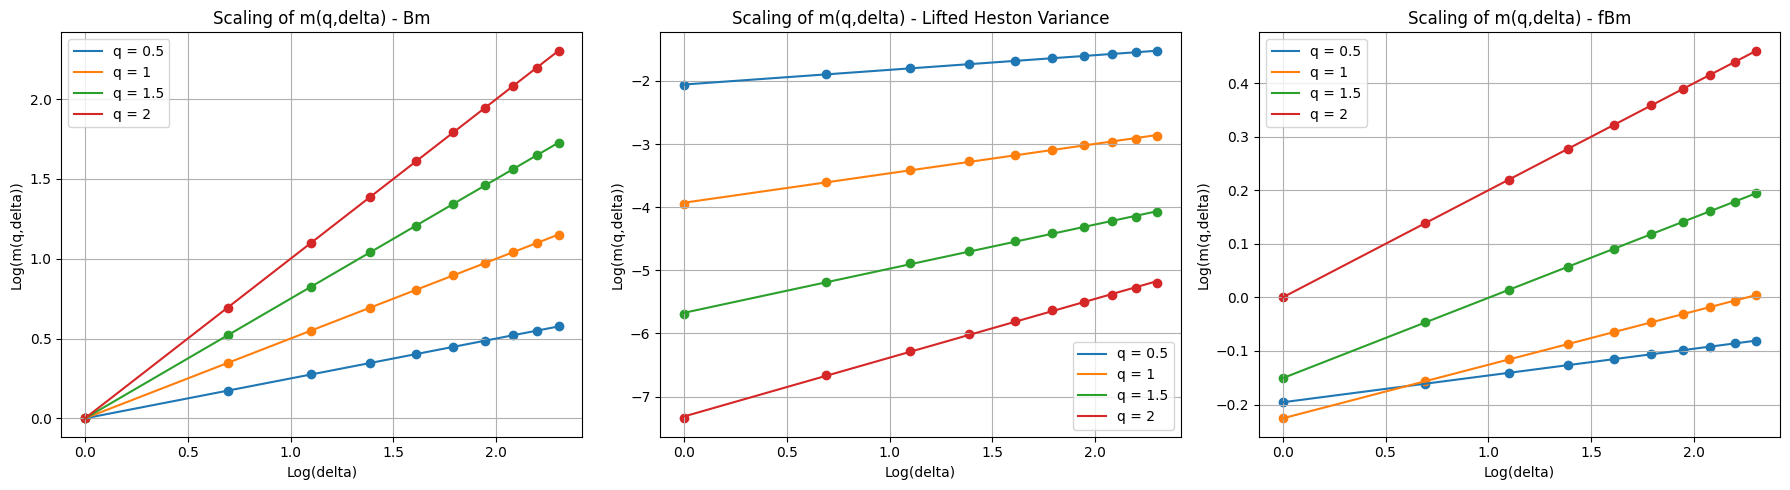

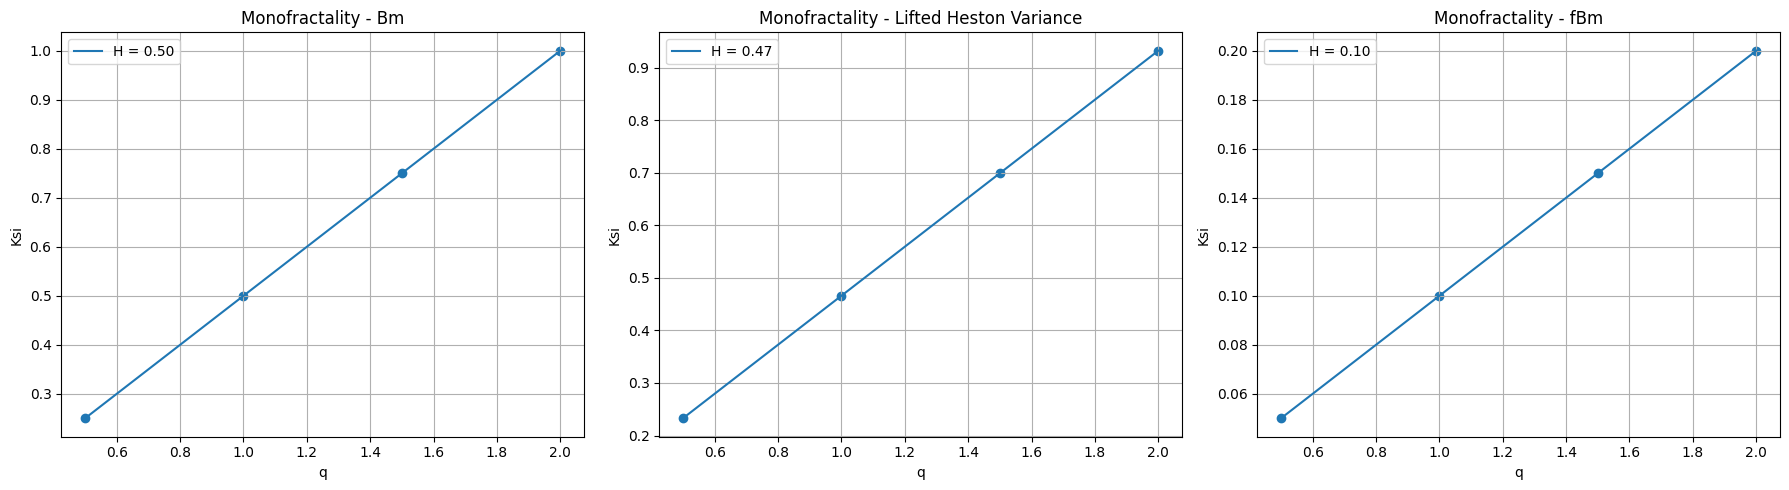

In [11]:
H_bm, slope_bm, intercept_bm, mo_bm = moment_bm(params1["q"], params1["delta"])
H_fbm, slope_fbm, intercept_fbm, mo_fbm = moment_fbm(params1["H_choice"], params1["q"], params1["delta"])
H_lh, slope_lh, intercept_lh, mo_lh = moment_lh(V, params1["q"], params1["delta"])

H_list = [H_bm, H_lh, H_fbm]
slopes = [slope_bm, slope_lh, slope_fbm]
intercepts = [intercept_bm, intercept_lh, intercept_fbm]
moments = [mo_bm, mo_lh, mo_fbm]
title = ["Bm", "Lifted Heston Variance", "fBm"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    for k in range(len(params1["q"])):
        axes[i].scatter(np.log(params1["delta"]), np.log(moments[i][k, :]))
        axes[i].plot(np.log(params1["delta"]), slopes[i][k] * np.log(params1["delta"]) + intercepts[i][k], label='q = {}'.format(params1["q"][k]))

    axes[i].set_title(f'Scaling of m(q,delta) - {title[i]}')
    axes[i].grid(True)
    axes[i].set_xlabel('Log(delta)')
    axes[i].set_ylabel('Log(m(q,delta))')
    axes[i].legend()

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes2[i].scatter(params1["q"], slopes[i])
    axes2[i].plot(params1["q"], H_list[i] * np.array(params1["q"]) + intercepts[i][-1], label=f'H = {H_list[i]:.2f}')
    axes2[i].set_title(f'Monofractality - {title[i]}')
    axes2[i].grid(True)
    axes2[i].set_xlabel('q')
    axes2[i].set_ylabel('Ksi')
    axes2[i].legend()

plt.tight_layout()
plt.show()

### 3 - Experiment 2: Intra-day Timescales

Functions

In [14]:
# Empirical moments from a simulated path
def moment_path(path, q, delta):
    mo = np.zeros((len(q), len(delta)))
    
    for k in range(len(q)):
        for i in range(len(delta)):
            d = int(delta[i])
            increments = np.abs(path[d:] - path[:-d])
            mo[k, i] = np.mean(increments ** q[k])
    
    H, slope, intercept = H_est(mo, q, delta)
    return H, slope, intercept, mo

# Returns H for a path lagged
def path_lagged(path, q, delta, l_values):

    H = []
    for l in tqdm(l_values, leave=False):
        subpath = path[::l]
        h, _, _, _ = moment_path(subpath, q, delta)
        H.append(float(h))
    return H


Input:

In [26]:
params2 = {
    "q": [0.5,1,1.5,2],
    "delta": [k for k in range(1,11)],
    "l_values": [k for k in range(1,61)]
}

Computation and output:

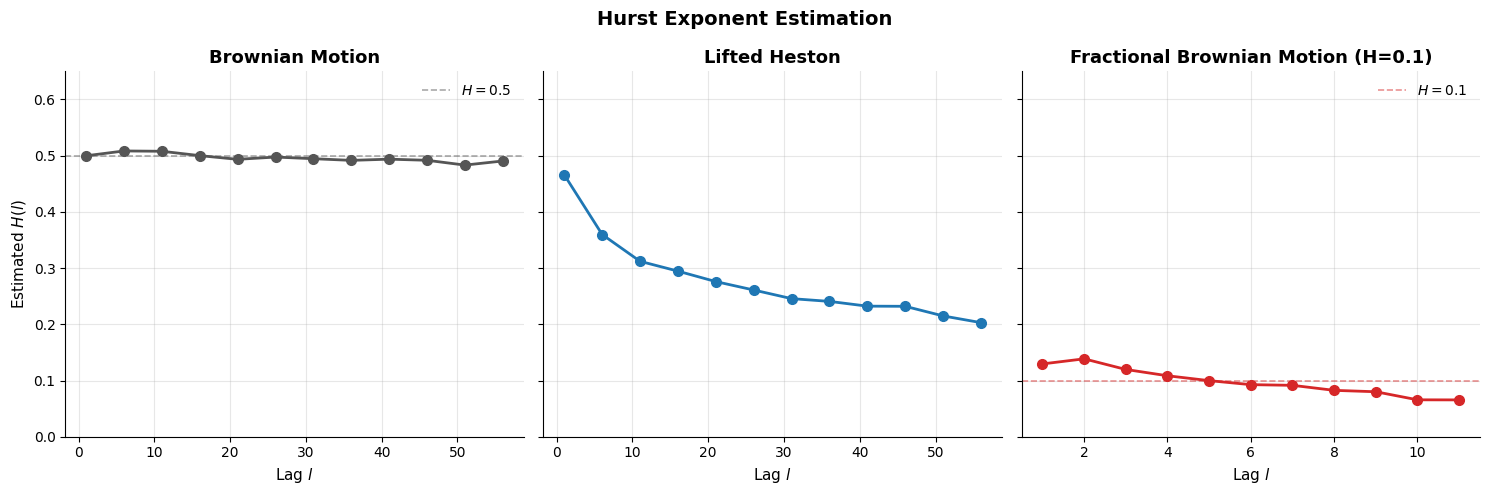

In [27]:
H_bm  = path_lagged(W, params2["q"], params2["delta"], params2["l_values"])
H_fbm = path_lagged(fW, params2["q"], params2["delta"], params2["l_values"])
H_lh  = path_lagged(V, params2["q"], params2["delta"], params2["l_values"])


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

processes = [
    {"ax": axes[0], "H": H_bm,  "label": "Brownian Motion", "color": "#555555", "H_true": 0.5},
    {"ax": axes[1], "H": H_lh,  "label": "Lifted Heston",   "color": "#1f77b4", "H_true": None},
    {"ax": axes[2], "H": H_fbm, "label": "Fractional Brownian Motion (H=0.1)",     "color": "#d62728", "H_true": 0.1},
]

for p in processes:
    ax = p["ax"]

    if p == processes[-1]:
        l_values = params2["l_values"][:11]
        ax.plot(l_values[:11], p["H"][:11], color=p["color"], linewidth=2, marker="o", markersize=7)
    else:
        l_values = params2["l_values"]
        ax.plot(l_values[::5], p["H"][::5], color=p["color"], linewidth=2, marker="o", markersize=7)

    if p["H_true"] is not None:
        ax.axhline(p["H_true"], color=p["color"], linestyle="--", linewidth=1.2,
                   alpha=0.5, label=f"$H = {p['H_true']}$")
        ax.legend(fontsize=10, frameon=False)

    ax.set_title(p["label"], fontsize=13, fontweight="bold")
    ax.set_xlabel("Lag $l$", fontsize=11)
    ax.set_ylim(0, 0.65)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Estimated $H(l)$", fontsize=11)
fig.suptitle("Hurst Exponent Estimation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


See full explanation and results in corresponding [doc](../docs/hurst_estimation.md)